# Time Series at Every Depth

Use the biophysics store of the ESA Mediterranean Sea Datacube to explore sea-water temperature through time and depth at one location in the Alboran Sea.

The data already have the water mask applied. This example opens one store, selects a location and year, and plots all available depths.

Choose either the local cluster or Dask Gateway setup below. Dask Gateway needs a configured cloud workspace. The copied setup imports `dask-gateway`; install that package in the notebook environment if it is not already available.

In [7]:
import dask.array as da
import dask.distributed
import warnings
import numpy as np
import xarray as xr
from dask.array.core import PerformanceWarning
# from dask_gateway import Gateway

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)


In [8]:
## run this line if you get a file system not found error!
# import os
# os.chdir("/tmp")
# print("cwd:", os.getcwd())

## Dask Cluster Setup

Use the Dask Gateway cells on the cloud workspace. For local runs, skip the Gateway cells and run the local alternative cell instead.

In [9]:
# Local alternative: run this cell instead of the Dask Gateway cells below.
cluster = dask.distributed.LocalCluster(
    n_workers=2,
    threads_per_worker=2,
    memory_limit="4GB",
)
client = dask.distributed.Client(cluster)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44107,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41061,Total threads: 2
Dashboard: http://127.0.0.1:46705/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:45857,


## Cloud Workspace

In [16]:
gateway = Gateway()
cluster_options = gateway.cluster_options()
cluster_options


In [ ]:
cluster = gateway.new_cluster(cluster_options=cluster_options)
cluster.scale(2)
cluster


In [ ]:
client = cluster.get_client()
client


In [12]:
import matplotlib.pyplot as plt

## Open the Biophysics Dataset

Open level `0` at full spatial resolution. The data remain lazy until we load the selected time series below.

In [11]:
INPUT_PATH = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/med_cubes/ocean-med-biophysics.zarr"

ds = xr.open_zarr(INPUT_PATH, group="0", chunks={}, consolidated=True, decode_coords="all")

## Select a Location and Year

`to` is sea-water temperature. Select the nearest grid point to 2.5°W, 36°N and keep every depth for 2019. Change the longitude, latitude, or dates to explore another location or period.

The selection stays lazy. Plotting below computes it using the active Dask client.

In [13]:
temperature = (
    ds["to"]
    .sel(lon=-2.5, lat=36.0, method="nearest")
    .sel(time=slice("2019-01-01", "2019-12-31"))
)
temperature

<xarray.DataArray 'to' (time: 365, depth: 18)> Size: 53kB
dask.array<getitem, shape=(365, 18), dtype=float64, chunksize=(7, 9), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
  * depth        (depth) float64 144B 3.0 5.0 7.0 10.0 ... 104.0 119.0 135.0
    lat          float32 4B 35.98
    lon          float32 4B -2.521
    spatial_ref  int64 8B ...
Attributes: (12/15)
    processing_steps:              {'regrid_func': 'regrid_kdtree_pyresample'...
    standard_name:                 sea_water_temperature
    long_name:                     temperature
    description:                   temperature
    units:                         degrees_C
    source:                        https://esa-earthcode.github.io/open-scien...
    ...                            ...
    file_type:                     area
    is_mask:                       False
    data_meaning:                  continuous
    valid_range:                   [9.2, 32.224000000000004]
    visualization_range:           [15.971, 18.224700000000002]
    aggregation_method:            mean

## Plot Temperature Through Time and Depth

Each row shows the temperature time series at a depth, with deeper water lower on the plot. Colour shows temperature, making seasonal warming and cooling easy to compare across depths.

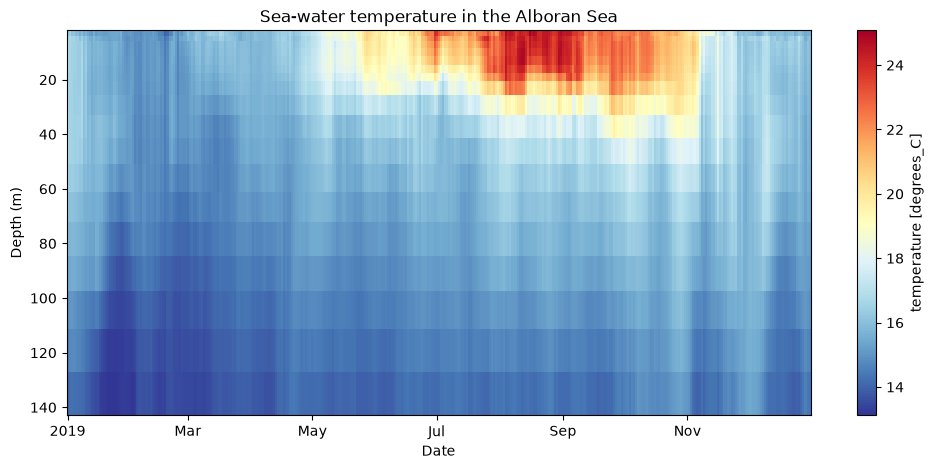

In [14]:
temperature.plot(
    x="time", y="depth", yincrease=False,
    cmap="RdYlBu_r", figsize=(12, 5),
)
plt.title("Sea-water temperature in the Alboran Sea")
plt.xlabel("Date")
plt.ylabel("Depth (m)")
plt.show()

In [15]:
ds.close()
client.close()
cluster.close()